In [2]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(stringr)
library(Seurat)
library(reshape)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘reshape’


The following object is masked from ‘package:dplyr’:

    rename


The following objects are masked from ‘package:tidyr’:

    expand, smiths




In [4]:
df <- read.csv("TCGA.BRCA.sampleMap_HiSeqV2", sep = '\t', row.names = 1)
meta <- read.csv("xena_primaries_meth450_brca_other_meta.tsv", sep = '\t', row.names = 1, na.strings=c("", " ", "NA"))

In [5]:
rownames(meta) <- gsub("-",".",rownames(meta))

In [6]:
df <- df[,which(colnames(df) %in% rownames(meta))]

In [7]:
tcga <- CreateSeuratObject(df, project = "tcga", assay = "RNA",
  min.cells = 0, min.features = 0, names.field = 1,
  names.delim = "_", meta.data = meta)
tcga

Warning message:
“Feature names cannot have pipe characters ('|'), replacing with dashes ('-')”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


An object of class Seurat 
20530 features across 1097 samples within 1 assay 
Active assay: RNA (20530 features, 0 variable features)
 1 layer present: counts

In [63]:
table(tcga$PAM50Call_RNAseq)


 Basal   Her2   LumA   LumB Normal 
   141     67    421    192     23 

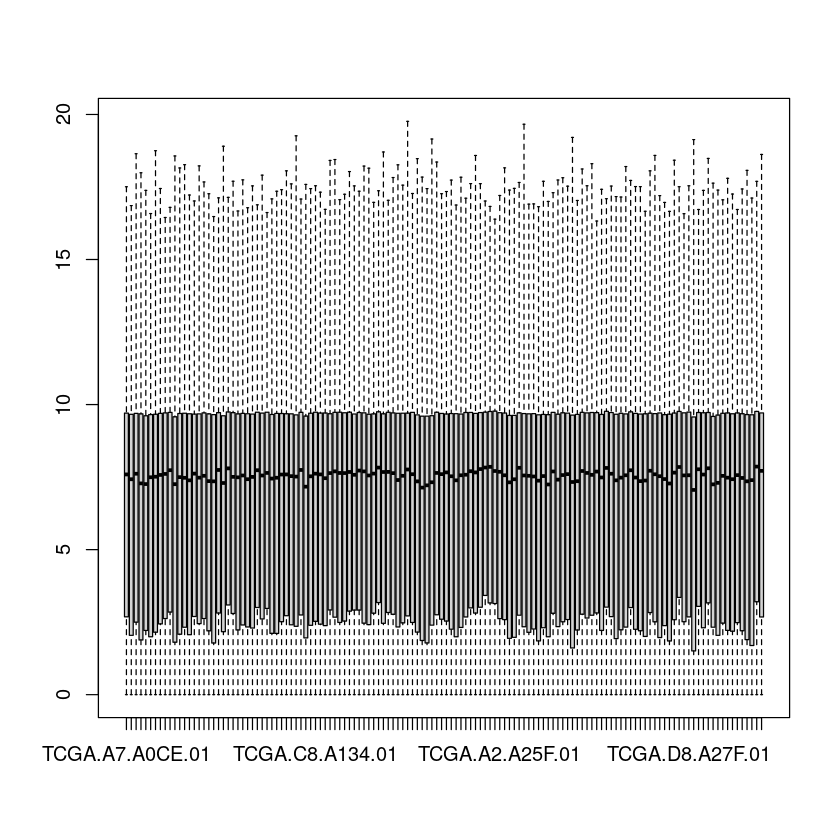

In [14]:
boxplot(counts)

In [8]:
subtyping <- read.csv("final_TNBC_subtyping_reassigned_tcga_basal_no_ER_flags.csv", row.names=1)

In [11]:
tcga <- AddMetaData(tcga, subtyping['final_subtype'], 'final_subtype')

ERROR: Error in eval(expr, envir, enclos): object 'tcga' not found


In [10]:
tcga <- subset(tcga, subset=final_subtype %in% c("BL1","BL2","LAR","M","UNC"))
tcga

Warning message:
“Removing 965 cells missing data for vars requested”


An object of class Seurat 
20530 features across 132 samples within 1 assay 
Active assay: RNA (20530 features, 0 variable features)
 1 layer present: counts

In [11]:
saveRDS(tcga, "tcga_basal_TNBC_subtyped.rds")

In [3]:
tcga <- readRDS("tcga_basal_TNBC_subtyped.rds")

In [9]:
tcga

An object of class Seurat 
20530 features across 132 samples within 1 assay 
Active assay: RNA (20530 features, 0 variable features)
 1 layer present: counts

In [17]:
# export to Scanpy for Velocity

# save metadata table:
tcga$barcode <- colnames(tcga)
write.csv(tcga@meta.data, file='tcga.metadata.csv', quote=F,row.names=F)

# write expression counts matrix
library(Matrix)
counts_matrix <- GetAssayData(tcga, assay='RNA', slot='counts')
writeMM(counts_matrix, file='tcga.counts.mtx')

# write gene names
write.table(
  data.frame('gene'=rownames(counts_matrix)),file='tcga.gene.names.csv',
  quote=F,row.names=F,col.names=F
) 

NULL

In [5]:
table(tcga$final_subtype)


BL1 BL2 LAR   M UNC 
 40  32  14  44   2 

In [16]:
colnames(tcga[[]])

[1] "orig.ident"                      "nCount_RNA"                     
 [3] "nFeature_RNA"                    "samples"                        
 [5] "cg11964474"                      "cg25738236"                     
 [7] "cg06973652"                      "cg05815247"                     
 [9] "cg10609677"                      "cg27581762"                     
[11] "cg19442659"                      "cg24900425"                     
[13] "cg26370022"                      "cg11529738"                     
[15] "cg19454999"                      "cg25288140"                     
[17] "cg14687474"                      "cg18372208"                     
[19] "cg16006004"                      "cg14947218"                     
[21] "cg02286533"                      "cg06001716"                     
[23] "cg26276233"                      "cg25067162"                     
[25] "cg09831010"                      "cg12182452"                     
[27] "cg11126247"                      "cg10893007"                     
[29] "cg20760063"                      "cg26891576"                     
[31] "cg09441966"                      "cg17301289"                     
[33] "cg04658354"                      "cg04110421"                     
[35] "cg21253966"                      "cg16630982"                     
[37] "cg16963062"                      "cg15419295"                     
[39] "cg20187250"                      "cg24806953"                     
[41] "cg08993267"                      "cg08386886"                     
[43] "cg19088651"                      "cg19531713"                     
[45] "cg12984107"                      "cg04582861"                     
[47] "cg13782816"                      "cg07054526"                     
[49] "cg18830083"                      "cg16919093"                     
[51] "cg16029534"                      "cg01879757"                     
[53] "histological_type"               "PAM50Call_RNAseq"               
[55] "TP63"                            "gender"                         
[57] "distant_metastasis_present_ind2" "TP53..average."                 
[59] "BRCA1..average."                 "anatomic_neoplasm_subdivision"  
[61] "initial_weight"                  "pathologic_stage"               
[63] "sample_type"                     "final_subtype"

In [19]:
table(tcga$histological_type)


 Infiltrating Ductal Carcinoma Infiltrating Lobular Carcinoma 
                           117                              2 
           Medullary Carcinoma          Metaplastic Carcinoma 
                             3                              2 
                Other, specify 
                             6 

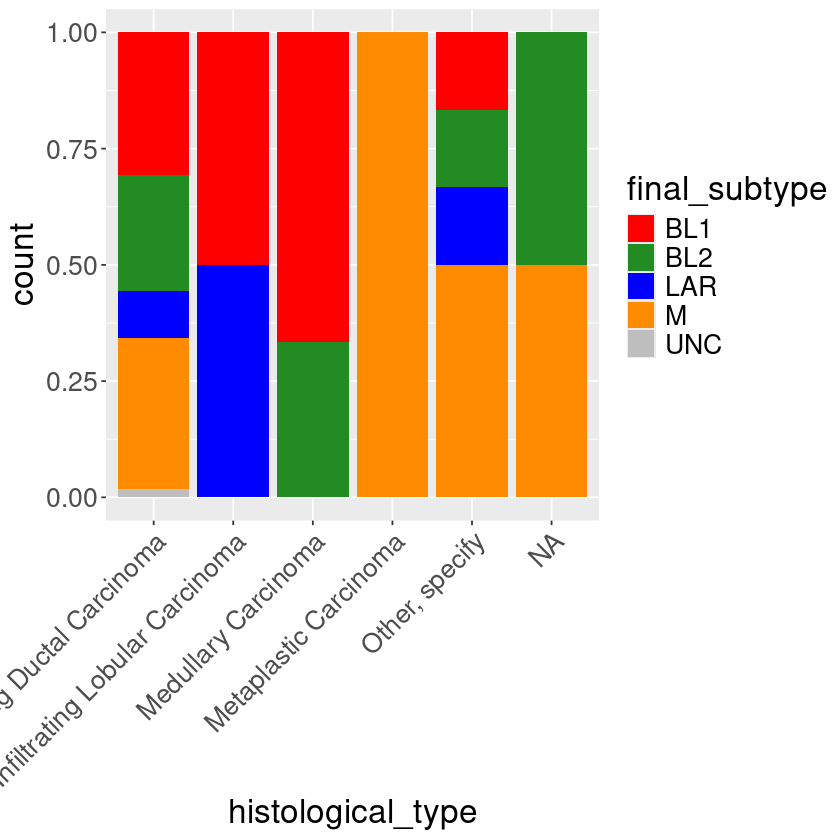

In [22]:
ggplot(tcga[[]], aes(x=histological_type,
                          fill=final_subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=20))+ 
scale_fill_manual(values=c("red","forestgreen","blue","darkorange","grey"))

#dev.off()

In [6]:
tcga <-NormalizeData(tcga)
all.genes <- rownames(tcga)
tcga <- ScaleData(tcga, features = all.genes)

Normalizing layer: counts

Centering and scaling data matrix



In [7]:
Idents(tcga) <- "final_subtype"

In [8]:
rna.mark <- FindAllMarkers(tcga, only.pos = TRUE, )

Calculating cluster M

Calculating cluster UNC

Calculating cluster BL2

Calculating cluster BL1

Calculating cluster LAR



In [9]:
dim(rna.mark)
mark <- rna.mark[ grep("RP", rna.mark$gene, invert = TRUE) , ]
mark <- mark[ grep("RBP", mark$gene, invert = TRUE) , ]
mark <- mark[ grep("MT", mark$gene, invert = TRUE) , ]
mark <- mark[ grep("RNA", mark$gene, invert = TRUE) , ]

dim(mark)

[1] 3646    7

[1] 3536    7

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


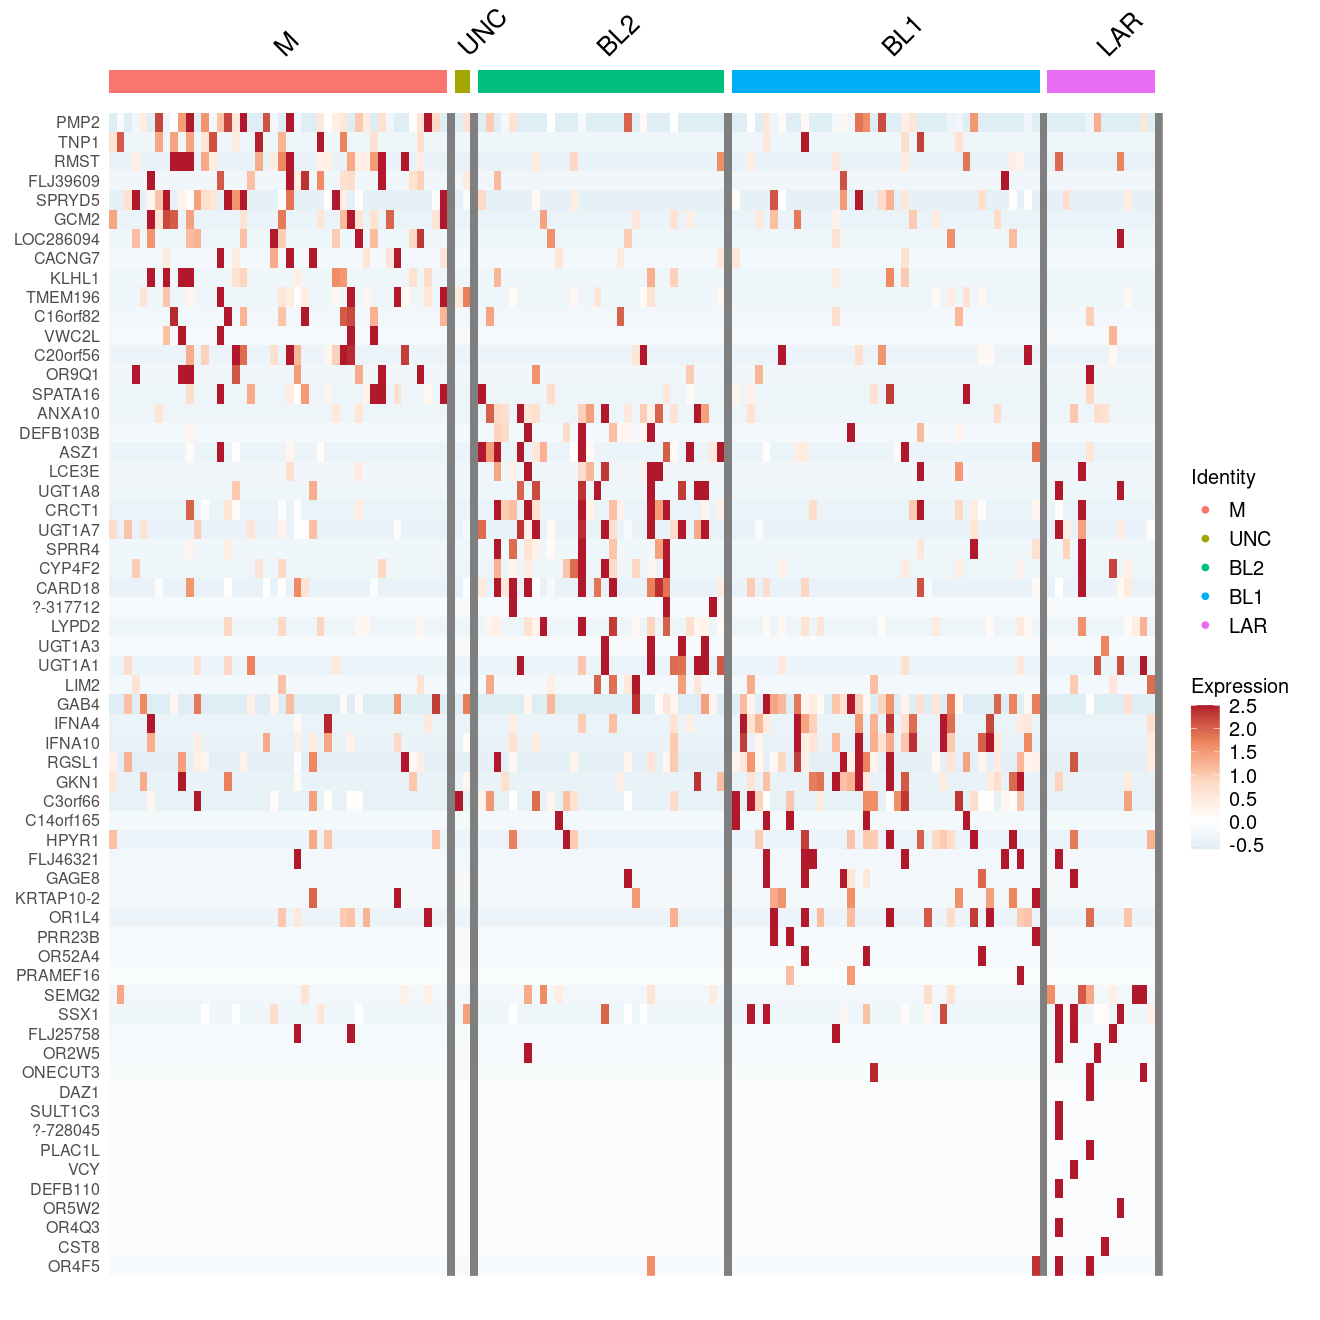

In [14]:
tcga <- ScaleData(tcga, verbose = FALSE)

options(repr.plot.height = 11,repr.plot.width = 11)

mark %>%
    group_by(cluster) %>%
    top_n(n = 15, wt = avg_log2FC) -> top10

#pdf("final_subtype_heatmap.pdf",width=11, height=11)

DoHeatmap(tcga, features = top10$gene)+ 
    theme(text = element_text(size = 12))+ 
theme(legend.text  = element_text(size = 12))+scale_fill_gradient2( low = rev(c('#d1e5f0','#67a9cf','#2166ac')), mid = "white", high = rev(c('#b2182b','#ef8a62','#fddbc7')), midpoint = 0, guide = "colourbar")

#dev.off()

In [44]:
mesenchymal <- rna.mark[which(rna.mark$cluster == "M"),]

In [52]:
mes_sig <- mesenchymal[which(mesenchymal$p_val_adj < 0.05),'gene']

In [53]:
mes_sig

[1] "KLHDC8A"   "BRSK1"     "SEPT5"     "KIAA1549"  "ENPP1"     "KCNK2"    
 [7] "C19orf44"  "NXPH3"     "ATL1"      "VPS37D"    "C1orf133"  "C20orf117"
[13] "SEMA6C"    "SMO"       "SH3RF1"    "NRTN"      "GEFT"      "DLX1"     
[19] "FAM101B"   "DIRAS1"    "TMEM98"    "UNC119B"   "PDE5A"     "GDF1"     
[25] "SLC45A1"   "ADAMTS19"  "C12orf53"

In [11]:
mesenchymal_df <- mesenchymal %>%
  arrange(desc(p_val))#p_val,avg_log2FC

In [12]:
mesenchymal_df$rank <- 1:nrow(mesenchymal_df)

In [13]:
rownames(mesenchymal_df)

[1] "KLK14"        "CLIP3"        "LOC100130093" "RRH"         
   [5] "OR52W1"       "AQP2"         "IL17D"        "PCDH18"      
   [9] "TRDMT1"       "SETBP1"       "INHA"         "CRIP3"       
  [13] "PSG10"        "SPATA16"      "TRIML1"       "GSTM3"       
  [17] "FHL1"         "SERPINB5"     "CHST10"       "ZNF610"      
  [21] "FEZ1"         "C14orf37"     "ISM1"         "KCNG1"       
  [25] "CLEC11A"      "C12orf73"     "C18orf54"     "RIMS3"       
  [29] "SSTR4"        "ZNF660"       "CDH12"        "C4orf39"     
  [33] "PHYHIPL"      "KCNAB1"       "KIRREL"       "CRYAB"       
  [37] "BEX5"         "GRIK2"        "C2orf40"      "CLEC2L"      
  [41] "MATN3"        "LOC654342"    "TMEM84"       "ARSJ"        
  [45] "EHD3"         "OR9Q1"        "PGF"          "FAM161A"     
  [49] "CPS1"         "HOXA6"        "CAPZA3"       "KLHL13"      
  [53] "CACNA2D2"     "C20orf56"     "RNF165"       "PSD"         
  [57] "GPR162"       "ZNF439"       "SFRP1"        "ETV5"        
  [61] "LOC284009"    "C7orf52"      "ZNF579"       "IGF2"        
  [65] "FAM154B"      "IL11"         "ADH6"         "MUC7"        
  [69] "ZNF385D"      "EBF4"         "TMEM117"      "WNT2B"       
  [73] "STXBP1"       "FAM180B"      "GATSL1"       "C8ORFK29"    
  [77] "KIRREL3"      "RFX4"         "ZNF709"       "KLHL23"      
  [81] "PART1"        "VWC2L"        "GRIN2C"       "CA3"         
  [85] "TCEAL2"       "LHX9"         "UNC5D"        "GBX1"        
  [89] "AADAT"        "RTN4R"        "NAV3"         "DPY19L2P2"   
  [93] "RNF208"       "PDZD4"        "ST8SIA1"      "HLF"         
  [97] "MSI2"         "CACNB1"       "CDCA7L"       "ZNF432"      
 [101] "RIMS1"        "C6orf122"     "BGLAP"        "C6orf154"    
 [105] "MAFA"         "LCA5"         "SLC43A1"      "DLG4"        
 [109] "MAP1D"        "P4HA3"        "LOC283867"    "C12orf50"    
 [113] "LCN1"         "HAPLN2"       "AGPAT4"       "GSG1L"       
 [117] "C16orf82"     "UCMA"         "MAGEL2"       "ZNF844"      
 [121] "MYT1"         "C2orf81"      "NKX3-2"       "MYH11"       
 [125] "MFAP2"        "GPR173"       "HOXC13"       "RSPH9"       
 [129] "MAPK4"        "SCML2"        "CDH6"         "PTGS2"       
 [133] "C7orf53"      "OXTR"         "TMEM81"       "TPPP3"       
 [137] "SEMA5B"       "PRRT1"        "MFRP"         "PSD3"        
 [141] "NR2F1"        "TAF7L"        "FAM186B"      "PABPC1L"     
 [145] "RAB3A"        "COL8A1"       "NAP1L3"       "PDZD7"       
 [149] "XKR5"         "RGS5"         "GDPD2"        "GOLGA6L9"    
 [153] "CTU1"         "LRRC66"       "PDE9A"        "SC65"        
 [157] "MAST1"        "FAT3"         "EFCAB1"       "C9orf4"      
 [161] "SNORA49"      "PALM3"        "ODF4"         "TMEM196"     
 [165] "EBF2"         "SRPX"         "PNMA3"        "ST6GAL2"     
 [169] "CAMKV"        "CLEC18C"      "HSPB7"        "PNMA6A"      
 [173] "LOC100190938" "KRT83"        "GRP"          "TREH"        
 [177] "C6orf141"     "TMOD2"        "ERG"          "ARHGEF33"    
 [181] "GATS"         "EPHB1"        "SRCIN1"       "C9orf110"    
 [185] "SHISA4"       "MYLPF"        "FGF17"        "ZBTB12"      
 [189] "ZNF643"       "CRISPLD1"     "SPON1"        "IRGC"        
 [193] "ZNF193"       "TMEM35"       "BHLHB9"       "LTBP4"       
 [197] "GOLT1A"       "TYR"          "TMEM174"      "LOC148709"   
 [201] "TSPAN12"      "OTUD3"        "CHRNA2"       "GNG13"       
 [205] "C2orf88"      "RGL3"         "DTX1"         "DZIP1"       
 [209] "ZMYND10"      "NOVA2"        "KCNMB1"       "SEPT3"       
 [213] "GPR22"        "JPH3"         "CCDC157"      "MANSC1"      
 [217] "FBN3"         "TMPRSS9"      "PDZK1"        "CAMK2B"      
 [221] "LRRC67"       "DMP1"         "CA13"         "ACAN"        
 [225] "MYLK"         "DRD2"         "PURG"         "FITM2"       
 [229] "SNED1"        "RTN4RL2"      "GALNTL2"      "DNALI1"      
 [233] "KIAA1024"     "C2orf77"      "TMEM198"      "CHADL"       
 [237] "HS6ST3"       "TMEM90B"      "RNF112"     

In [15]:
write.csv(mesenchymal_df, "tcga_mesenchymal_genes_as_human.csv")

In [27]:
x <- rownames(mesenchymal_df)
output = c()

test <- for (i in 1:length(x)) {  
  if (x[i] %in% df_merge$Symbol.x) {
      y <- which(df_merge$Symbol.x == x[i])
      y <- y[1]
      output = append(output,df_merge[y,3])
    } else {output = append(output,x[i])}
}

length(output)


genes_upper <- sapply(X = output, FUN = function(x) {
    x <- str_to_sentence(x)
})

genes_upper <- as.data.frame(genes_upper)

#mesenchymal_wap_overlap$names <- genes_upper$genes_upper

head(genes_upper)

[1] 1023

,genes_upper
,<chr>
1,Klk14
2,Clip3
3,Loc100130093
4,Rrh
5,Or52w1
6,Aqp2


In [28]:
write.csv(genes_upper, "tcga_mesenchymal_genes_as_mouse.csv")

In [38]:
wap_cre_deg <- read.csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_scanpy/humanized_wap_sig_degs_resampled_tumor_vs_all_else_normal_wilcox.csv", row.names = 1)

In [39]:
mesenchymal_wap_overlap <- mesenchymal_df[which(mesenchymal_df$gene %in% wap_cre_deg$names),]

mesenchymal_wap_overlap_genes <- mesenchymal_wap_overlap$gene

mesenchymal_wap_overlap_genes

[1] "PCDH18"   "GSTM3"    "CLEC11A"  "CRYAB"    "PGF"      "SFRP1"   
 [7] "ETV5"     "TMEM117"  "LHX9"     "PDZD4"    "RIMS1"    "MFAP2"   
[13] "CDH6"     "EBF2"     "ERG"      "CHADL"    "CSPG4"    "CDH2"    
[19] "TRNP1"    "MIA"      "ADAMTS7"  "HMCN1"    "NDRG2"    "SHANK1"  
[25] "BCL11A"   "TBX2"     "FREM2"    "HMGA2"    "GJC1"     "LOXL3"   
[31] "AHI1"     "SLC29A4"  "PABPC4L"  "BEGAIN"   "MEX3B"    "GPX7"    
[37] "H19"      "SEMA5A"   "OSR1"     "SCUBE3"   "MLLT11"   "LRP12"   
[43] "MEGF10"   "XYLT1"    "ARHGDIG"  "GCAT"     "OLFML2A"  "NTF3"    
[49] "LRIG3"    "CSRP2"    "HSPB2"    "ITGA9"    "EFNA3"    "PID1"    
[55] "GPC2"     "C2CD4D"   "MYEF2"    "RNF144A"  "SOX10"    "TMEM108" 
[61] "COL2A1"   "SGCD"     "ACTR3B"   "PGBD1"    "VCAN"     "SLC35F1" 
[67] "MFAP3L"   "CNIH2"    "CCDC74A"  "PODXL2"   "KCNMB4"   "NALCN"   
[73] "NHSL1"    "TTYH1"    "SOSTDC1"  "LZTS1"    "COL9A1"   "PCYT1B"  
[79] "SHF"      "EPHA7"    "PLP1"     "ETV4"     "NGF"      "CRLF1"   
[85] "EDIL3"    "CADM1"    "CACHD1"   "NT5DC2"   "SBK1"     "MMP16"   
[91] "TMEM121"  "PCBP4"    "ID4"      "CTXN1"    "CHRM3"    "COL9A3"  
[97] "SCRG1"    "ENPP1"    "KIAA1549"

In [40]:
mesenchymal_wap_overlap <- mesenchymal_df[which(mesenchymal_df$gene %in% wap_cre_deg$names),]

mesenchymal_wap_overlap_ranks <- mesenchymal_wap_overlap$rank

mesenchymal_wap_overlap_ranks

[1]    8   16   25   36   47   59   60   71   86   94  101  125  131  165  179
[16]  236  243  257  300  304  305  309  328  333  342  371  387  391  432  446
[31]  451  471  472  475  476  492  495  499  529  533  561  564  568  576  578
[46]  582  600  602  633  645  661  670  687  698  709  712  713  719  732  758
[61]  768  771  772  780  781  784  786  795  799  801  817  820  821  846  864
[76]  866  873  881  886  887  892  898  913  916  923  930  935  938  946  950
[91]  954  955  962  969  989  992  993 1019 1020

In [82]:
length(mesenchymal_wap_overlap_genes)

[1] 99

In [26]:
write.csv(mesenchymal_wap_overlap, "tcga_mesenchymal_wap_overlap_genes.csv")

In [27]:
wap_cre_deg_df <- wap_cre_deg %>%
  arrange(desc(pvals_adj))

wap_cre_deg_df$rank <- 1:nrow(wap_cre_deg_df)

In [28]:
mesenchymal_wap_overlap <- wap_cre_deg_df[which(wap_cre_deg_df$names %in% mesenchymal_df$gene),]

mesenchymal_wap_overlap_genes <- mesenchymal_wap_overlap$names

mesenchymal_wap_overlap_genes

[1] "EBF2"     "TTYH1"    "PGBD1"    "RIMS1"    "SGCD"     "ERG"     
 [7] "LHX9"     "CCDC74A"  "MEX3B"    "H19"      "ACTR3B"   "C2CD4D"  
[13] "EFNA3"    "LZTS1"    "BEGAIN"   "ADAMTS7"  "NTF3"     "SHANK1"  
[19] "LOXL3"    "SBK1"     "PDZD4"    "PID1"     "TBX2"     "SCRG1"   
[25] "MEGF10"   "SLC29A4"  "CNIH2"    "HMGA2"    "HSPB2"    "CDH6"    
[31] "GPC2"     "PABPC4L"  "CSPG4"    "COL2A1"   "CDH2"     "NGF"     
[37] "MFAP2"    "TMEM108"  "MFAP3L"   "MMP16"    "PLP1"     "SCUBE3"  
[43] "LRP12"    "OLFML2A"  "RNF144A"  "PCYT1B"   "GJC1"     "EDIL3"   
[49] "PODXL2"   "SLC35F1"  "ARHGDIG"  "GCAT"     "CLEC11A"  "GPX7"    
[55] "KIAA1549" "TRNP1"    "FREM2"    "KCNMB4"   "TMEM121"  "PGF"     
[61] "LRIG3"    "XYLT1"    "PCDH18"   "CRLF1"    "NT5DC2"   "CTXN1"   
[67] "NALCN"    "MLLT11"   "CACHD1"   "ITGA9"    "COL9A1"   "ETV4"    
[73] "TMEM117"  "NDRG2"    "CHRM3"    "OSR1"     "SFRP1"    "AHI1"    
[79] "PCBP4"    "MYEF2"    "CRYAB"    "EPHA7"    "CHADL"    "SHF"     
[85] "CSRP2"    "SOSTDC1"  "ETV5"     "HMCN1"    "GSTM3"    "SOX10"   
[91] "ID4"      "NHSL1"    "VCAN"     "SEMA5A"   "CADM1"    "MIA"     
[97] "ENPP1"    "COL9A3"   "BCL11A"

In [29]:
mesenchymal_wap_overlap <- wap_cre_deg_df[which(wap_cre_deg_df$names %in% mesenchymal_df$gene),]

mesenchymal_wap_overlap_ranks <- mesenchymal_wap_overlap$rank

mesenchymal_wap_overlap_ranks

[1]   14   66   89   94   95  134  169  170  219  224  250  252  261  269  272
[16]  276  282  284  293  317  333  359  375  381  382  385  392  402  428  435
[31]  475  501  506  553  577  589  592  600  602  622  647  655  670  673  678
[46]  683  687  700  703  705  710  731  773  777  780  797  798  849  851  863
[61]  886  888  911  918  930  934  937  941  953  963  971  979  985  994 1004
[76] 1019 1024 1046 1049 1052 1073 1076 1078 1117 1127 1136 1141 1165 1183 1185
[91] 1188 1194 1204 1216 1220 1221 1224 1232 1238

In [16]:
#make these genes mouse

mouse_human_genes = readRDS("/share/crsp/lab/dalawson/tzhuravl/TCGA/mouse_human_genes.rds")

mouse <- mouse_human_genes[which(mouse_human_genes['Common.Organism.Name']=="mouse, laboratory"),c(1,4)]
mouse = mouse[!duplicated(mouse$Symbol),]
dim(mouse)

human <- mouse_human_genes[which(mouse_human_genes['Common.Organism.Name']=="human"),c(1,4)]
human = human[!duplicated(human$Symbol),]
dim(human)

df_merge <- merge(human,mouse,by="DB.Class.Key")
dim(df_merge)
head(df_merge)

[1] 21810     2

[1] 19324     2

[1] 19323     3

,DB.Class.Key,Symbol.x,Symbol.y
,<int>,<chr>,<chr>
1,47114598,BANF1,Banf1
2,47114599,PDE9A,Pde9a
3,47114600,ASRGL1,Asrgl1
4,47114601,CLPB,Clpb
5,47114602,EMD,Emd
6,47114603,ANXA1,Anxa1


In [31]:
x <- mesenchymal_wap_overlap$names
output = c()

test <- for (i in 1:length(x)) {  
  if (x[i] %in% df_merge$Symbol.x) {
      y <- which(df_merge$Symbol.x == x[i])
      y <- y[1]
      output = append(output,df_merge[y,3])
    } else {output = append(output,x[i])}
}

length(output)


genes_upper <- sapply(X = output, FUN = function(x) {
    x <- str_to_sentence(x)
})

genes_upper <- as.data.frame(genes_upper)

mesenchymal_wap_overlap$names <- genes_upper$genes_upper

head(mesenchymal_wap_overlap)

[1] 99

,names,scores,logfoldchanges,pvals,pvals_adj,rank
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
14,Ebf2,2.470177,5.081798,0.013504622,0.042826779,14
66,Ttyh1,2.732482,3.910944,0.006285914,0.020753882,66
89,Pgbd1,2.788516,1.565361,0.005295021,0.017652111,89
94,Rims1,2.819012,3.196106,0.004817175,0.016131855,94
95,Sgcd,2.819299,3.687950,0.004812870,0.016119313,95
134,Erg,3.019493,3.628038,0.002531984,0.008788478,134


In [32]:
write.csv(mesenchymal_wap_overlap, "tcga_mesenchymal_wap_overlap_genes_as_mouse.csv")

In [33]:
features=c("ACTA2","TAGLN","MYLK","KRT5","KRT14","TP63","WFDC2","EHF","ELF5","KIT","KRT8","KRT18",
           "GCAT","FREM2","LRIG3","NT5DC2","CACHD1","SOSTDC1")

In [64]:

features=c("ACTA2","TAGLN","MYLK","KRT5","KRT14","rna_TP63","WFDC2","EHF","ELF5","KIT","KRT8","KRT18",
           mesenchymal_wap_overlap_genes)

In [65]:
Idents(tcga) <- "final_subtype"

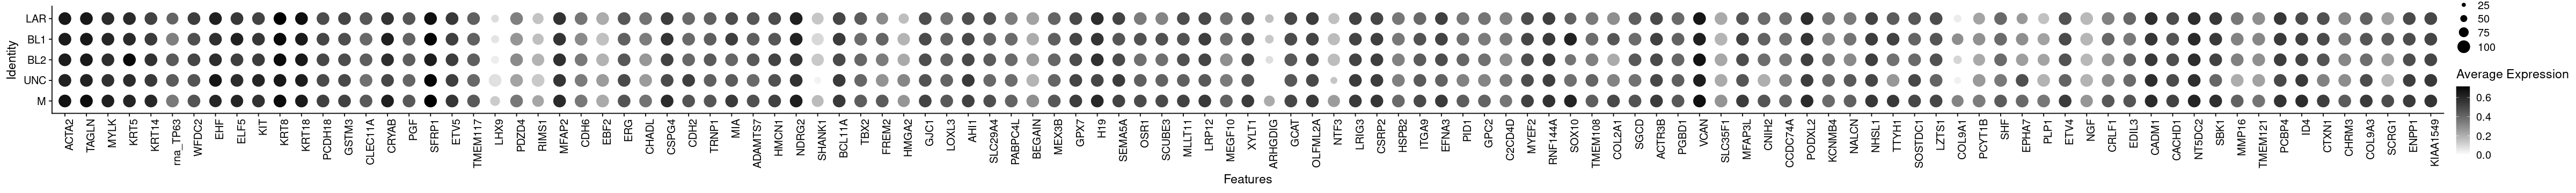

In [66]:
options(repr.plot.height = 3,repr.plot.width = 40)

DotPlot(
  tcga,
  features,
  assay = NULL,
  cols = c("white", "black", "black"),
  dot.min = 0,
  dot.scale = 6,
  idents = NULL,
  group.by = NULL,
  split.by = NULL,
  cluster.idents = FALSE,
  scale = FALSE,
  scale.by = "radius",
  scale.min = NA,
  scale.max = NA
)+ theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [16]:
Idents(tcga) <- "final_subtype"
tcga <- RenameIdents(tcga, 
                            `BL1` = "Other", 
                            `BL2` = "Other",
                            `LAR` = "Other",
                            `M` = "M", 
                            `UNC` = "Other")
tcga$subtype_other <- tcga@active.ident

In [69]:
Idents(tcga) <- "subtype_other"

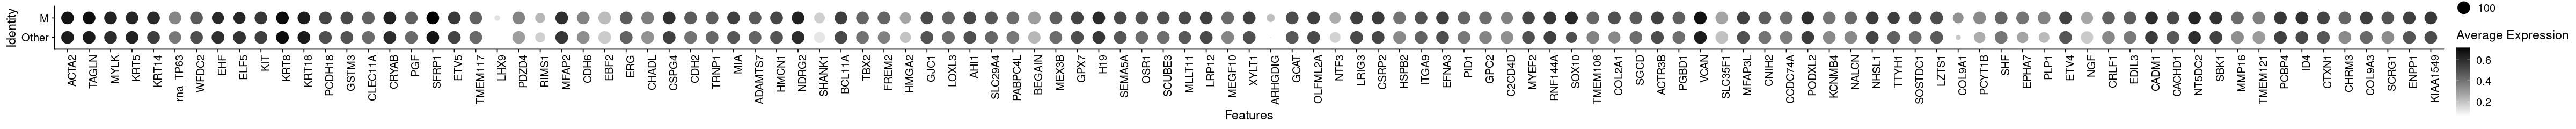

In [70]:
options(repr.plot.height = 2,repr.plot.width = 40)

DotPlot(
  tcga,
  features,
  assay = NULL,
  cols = c("white", "black", "black"),
  dot.min = 0,
  dot.scale = 6,
  idents = NULL,
  group.by = NULL,
  split.by = NULL,
  cluster.idents = FALSE,
  scale = FALSE,
  scale.by = "radius",
  scale.min = NA,
  scale.max = NA
)+ theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [73]:
nathanson_M <- readRDS("/share/crsp/lab/dalawson/share/BRCA_Nathanson_bulk/mesenchymal_DEGs.rds")

In [77]:
mesenchymal_df <- mesenchymal %>%
  arrange(desc(p_val))#p_val,avg_log2FC

mesenchymal_df$rank <- 1:nrow(mesenchymal_df)

In [79]:
tcga_nathanson_overlap <- mesenchymal_df[which(mesenchymal_df$gene %in% nathanson_M$gene),]

tcga_nathanson_overlap_genes <- tcga_nathanson_overlap$rank

tcga_nathanson_overlap_genes

[1]   21   23   30   35   36   59   60   70   99  124  125  127  129  167  190
 [16]  205  216  295  311  323  324  328  336  354  361  371  382  387  392  393
 [31]  407  420  431  433  441  463  473  478  483  485  498  515  518  529  546
 [46]  548  549  553  554  568  576  581  582  583  587  588  602  633  664  694
 [61]  705  718  719  727  731  732  734  736  740  742  748  752  753  756  757
 [76]  774  786  789  795  796  823  827  836  837  839  840  846  848  854  864
 [91]  868  874  886  893  898  901  903  905  910  918  922  923  925  929  930
[106]  935  950  951  953  958  960  961  968  972  978  983  989  992  993 1001
[121] 1004 1009 1018 1020

In [80]:
tcga_nathanson_overlap <- mesenchymal_df[which(mesenchymal_df$gene %in% nathanson_M$gene),]

tcga_nathanson_overlap_genes <- tcga_nathanson_overlap$gene

tcga_nathanson_overlap_genes

[1] "FEZ1"     "ISM1"     "ZNF660"   "KIRREL"   "CRYAB"    "SFRP1"   
  [7] "ETV5"     "EBF4"     "CDCA7L"   "MYH11"    "MFAP2"    "HOXC13"  
 [13] "MAPK4"    "PNMA3"    "CRISPLD1" "C2orf88"  "MANSC1"   "BTBD18"  
 [19] "SOX8"     "DDN"      "MSI1"     "NDRG2"    "ZNF469"   "SHC2"    
 [25] "TET1"     "TBX2"     "RASSF8"   "FREM2"    "SYNPO2L"  "KCNK5"   
 [31] "SP4"      "OBSL1"    "TOX3"     "S100A1"   "EPHB3"    "FOLH1"   
 [37] "ZBTB20"   "ARMCX2"   "SPATA6"   "PDC"      "TMPRSS5"  "TTC28"   
 [43] "DIP2C"    "OSR1"     "SOX6"     "RAB36"    "ITGA10"   "TRPC1"   
 [49] "FAM189A2" "MEGF10"   "XYLT1"    "ZNF853"   "GCAT"     "SSBP2"   
 [55] "KHDRBS3"  "GPC1"     "NTF3"     "LRIG3"    "C2orf82"  "SHROOM4" 
 [61] "AIF1L"    "NEDD4L"   "RNF144A"  "DCHS1"    "ABTB2"    "SOX10"   
 [67] "CC2D2A"   "TTC23"    "FXYD6"    "FZD7"     "QRICH2"   "ZNF70"   
 [73] "MDFI"     "ROPN1B"   "GPRASP2"  "APBA1"    "MFAP3L"   "FGFRL1"  
 [79] "CNIH2"    "ESRRG"    "ZDHHC1"   "CCKBR"    "SLC4A3"   "NGEF"    
 [85] "FAM84A"   "LRP6"     "TTYH1"    "FOXP4"    "PNMAL1"   "SOSTDC1" 
 [91] "MAMLD1"   "PHLPP1"   "SHF"      "IGF1R"    "ETV4"     "EFS"     
 [97] "SHC4"     "HDAC4"    "SERTAD4"  "NKAIN2"   "GNAZ"     "EDIL3"   
[103] "SMTN"     "TGFB1I1"  "CADM1"    "CACHD1"   "MMP16"    "EFNB3"   
[109] "SLC39A10" "TRO"      "KALRN"    "FNDC4"    "IRX1"     "SLC22A17"
[115] "SCARF2"   "FZD1"     "CHRM3"    "COL9A3"   "SCRG1"    "PDE5A"   
[121] "TMEM98"   "SH3RF1"   "KCNK2"    "KIAA1549"

In [81]:
length(tcga_nathanson_overlap_genes)

[1] 124

In [85]:
tcga_nathanson_overlap <- tcga_nathanson_overlap[which(tcga_nathanson_overlap$gene %in% mesenchymal_wap_overlap_genes),]

tcga_nathanson_overlap_genes <- tcga_nathanson_overlap$rank

tcga_nathanson_overlap_genes

[1]   36   59   60  125  328  371  387  529  568  576  582  602  633  719  732
[16]  786  795  846  864  886  898  923  930  935  950  989  992  993 1020

In [86]:
tcga_nathanson_overlap <- tcga_nathanson_overlap[which(tcga_nathanson_overlap$gene %in% mesenchymal_wap_overlap_genes),]

tcga_nathanson_overlap_genes <- tcga_nathanson_overlap$gene

tcga_nathanson_overlap_genes

[1] "CRYAB"    "SFRP1"    "ETV5"     "MFAP2"    "NDRG2"    "TBX2"    
 [7] "FREM2"    "OSR1"     "MEGF10"   "XYLT1"    "GCAT"     "NTF3"    
[13] "LRIG3"    "RNF144A"  "SOX10"    "MFAP3L"   "CNIH2"    "TTYH1"   
[19] "SOSTDC1"  "SHF"      "ETV4"     "EDIL3"    "CADM1"    "CACHD1"  
[25] "MMP16"    "CHRM3"    "COL9A3"   "SCRG1"    "KIAA1549"

In [87]:
length(tcga_nathanson_overlap_genes)

[1] 29

In [88]:
features <- tcga_nathanson_overlap_genes[!tcga_nathanson_overlap_genes %in% c("H19","MYEF2","KIAA1549")]
length(features)

[1] 28

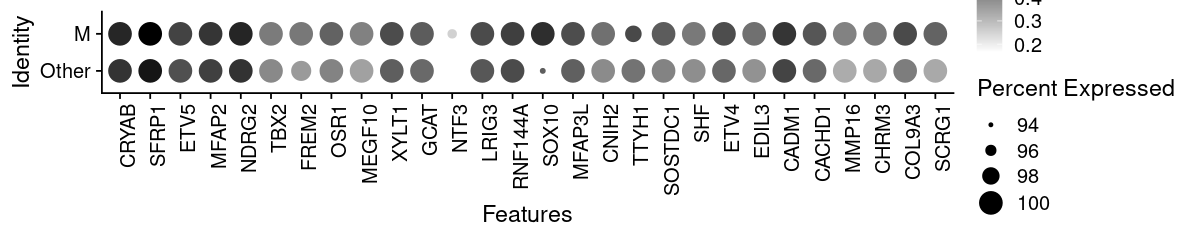

In [90]:
options(repr.plot.height = 2,repr.plot.width = 10)

DotPlot(
  tcga,
  features,
  assay = NULL,
  cols = c("white", "black", "black"),
  dot.min = 0,
  dot.scale = 6,
  idents = NULL,
  group.by = NULL,
  split.by = NULL,
  cluster.idents = FALSE,
  scale = FALSE,
  scale.by = "radius",
  scale.min = NA,
  scale.max = NA
)+ theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [93]:
write.csv(features, "tcga_nathanson_mesenchymal_wap_overlap_genes.csv")

In [94]:
x <- features
output = c()

test <- for (i in 1:length(x)) {  
  if (x[i] %in% df_merge$Symbol.x) {
      y <- which(df_merge$Symbol.x == x[i])
      y <- y[1]
      output = append(output,df_merge[y,3])
    } else {output = append(output,x[i])}
}

length(output)


genes_upper <- sapply(X = output, FUN = function(x) {
    x <- str_to_sentence(x)
})

genes_upper <- as.data.frame(genes_upper)

features <- genes_upper$genes_upper

features

[1] 28

[1] "Cryab"   "Sfrp1"   "Etv5"    "Mfap2"   "Ndrg2"   "Tbx2"    "Frem2"  
 [8] "Osr1"    "Megf10"  "Xylt1"   "Gcat"    "Ntf3"    "Lrig3"   "Rnf144a"
[15] "Sox10"   "Mfap3l"  "Cnih2"   "Ttyh1"   "Sostdc1" "Shf"     "Etv4"   
[22] "Edil3"   "Cadm1"   "Cachd1"  "Mmp16"   "Chrm3"   "Col9a3"  "Scrg1"

In [95]:
write.csv(features, "tcga_nathanson_mesenchymal_wap_overlap_genes_as_mouse.csv")

In [4]:
Idents(tcga) <- "final_subtype"

In [18]:
overlap <- read.csv("tcga_nathanson_mesenchymal_wap_overlap_genes.csv", row.names=2)

In [19]:
overlap=rownames(overlap)

In [20]:
overlap

[1] "CRYAB"   "SFRP1"   "ETV5"    "MFAP2"   "NDRG2"   "TBX2"    "FREM2"  
 [8] "OSR1"    "MEGF10"  "XYLT1"   "GCAT"    "NTF3"    "LRIG3"   "RNF144A"
[15] "SOX10"   "MFAP3L"  "CNIH2"   "TTYH1"   "SOSTDC1" "SHF"     "ETV4"   
[22] "EDIL3"   "CADM1"   "CACHD1"  "MMP16"   "CHRM3"   "COL9A3"  "SCRG1"

Warning message:
“No layers found matching search pattern provided”
Warning message in FetchData.Assay5(object = object[[DefaultAssay(object = object)]], :
“data layer is not found and counts layer is used”


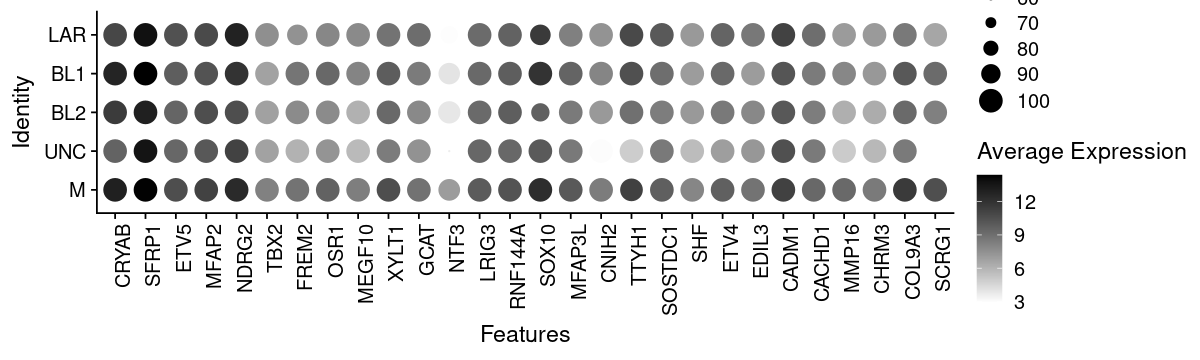

In [24]:
options(repr.plot.height = 3,repr.plot.width = 10)

DotPlot(
  tcga,
  overlap,
  assay = NULL,
  cols = c("white", "black", "black"),
  dot.min = 0,
  dot.scale = 6,
  idents = NULL,
  group.by = NULL,
  split.by = NULL,
  cluster.idents = FALSE,
  scale = FALSE,
  scale.by = "radius",
  scale.min = NA,
  scale.max = NA
)+ theme(axis.text.x = element_text(angle = 90, hjust = 1))
